# Part 3: Multimodal Modeling & Evaluation

Now that we have both Contextual features (campaign budgets, target countries) and Visual features (ResNet PCA, brightness), we fuse them together and train our models!

### 1. The GroupKFold Problem
Standard Machine Learning splitting (like `train_test_split`) causes severe data leakage here. If an ad for 'Campaign X' is in the train set, and a slightly different ad for 'Campaign X' is in the test set, the model just memorizes the campaign. 

We use **GroupKFold** grouped by `campaign_id` to ensure the model evaluates on entirely unseen 'Cold Start' campaigns.

In [2]:
import pandas as pd
from sklearn.model_selection import GroupKFold

# Load the processed feature dataset
df = pd.read_parquet('../data/processed/feature_dataset.parquet')

print(f"Total Samples: {len(df)}")
print(f"Unique Campaigns: {df['campaign_id'].nunique()}")

# Setup GroupKFold
gkf = GroupKFold(n_splits=5)
for train_idx, val_idx in gkf.split(df, groups=df['campaign_id']):
    print(f"Train size: {len(train_idx)}, Val size: {len(val_idx)}")
    break  # Just show the first fold

Total Samples: 811
Unique Campaigns: 56
Train size: 648, Val size: 163


### 2. Training the Model
We train a LightGBM Regressor. LightGBM is perfect for this because it handles missing values and categorical features (like `country_code`) natively without massive One-Hot Encoding.

In [5]:
import lightgbm as lgb
from sklearn.metrics import r2_score

# Sample basic training on the first fold for Demonstration
train_data = df.iloc[train_idx]
val_data = df.iloc[val_idx]

# Select numerical features
features = [c for c in df.columns if c.startswith('vision_pca') or c in ['buy_rate_cpe', 'brightness_mean', 'visual_entropy', 'campaign_duration_days']]
target = 'engagement_rate'

In [7]:
model = lgb.LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=15,
    min_child_samples=20,
    random_state=42,
    verbosity=-1
)

model.fit(train_data[features], train_data[target])

# Predict on unseen campaigns
preds = model.predict(val_data[features])
r2 = r2_score(val_data[target], preds)
print(f"Validation R^2 (Demo Model): {r2:.4f}")

Validation R^2 (Demo Model): 0.2096


### 3. Feature Importance
Finally, we want to know *why* the model made its decisions. What drives Engagement Rate?

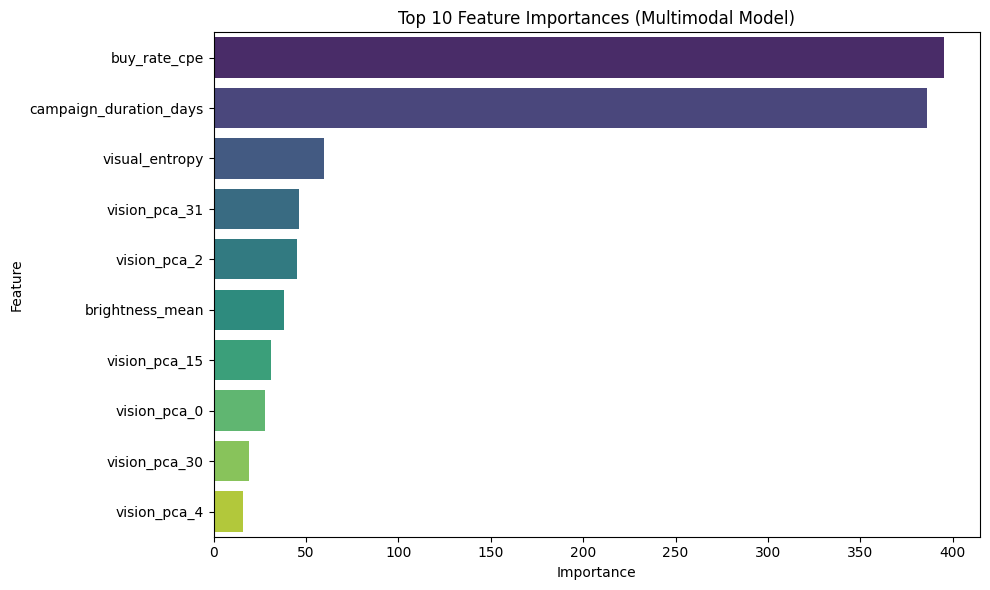

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract importances
importances = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importances.head(10),
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='viridis',
    legend=False
)

plt.title('Top 10 Feature Importances (Multimodal Model)')
plt.tight_layout()
plt.show()